Step1

This step imports required libraries for image classification. It sets dataset path, image size, batch size, and random seed to prepare for model training and ensure stable results.

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, models

DATASET_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_lab_activities/Assets/Insects_dataset'

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 123

print("Loading dataset and splitting 80% training / 20% validation...")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes identified: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Loading dataset and splitting 80% training / 20% validation...
Found 514 files belonging to 2 classes.
Using 412 files for training.
Found 514 files belonging to 2 classes.
Using 102 files for validation.
Classes identified: ['Train_data', 'test_data']


Step2: Optimize dataset performance
This step makes the dataset load faster and work better. We use AUTOTUNE to let the model prepare data while training. This saves time and makes the whole program run more smoothly.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Step 3: Data augmentation

This step uses data augmentation to make more training images. It uses random flip, rotation and zoom to stop overfitting.

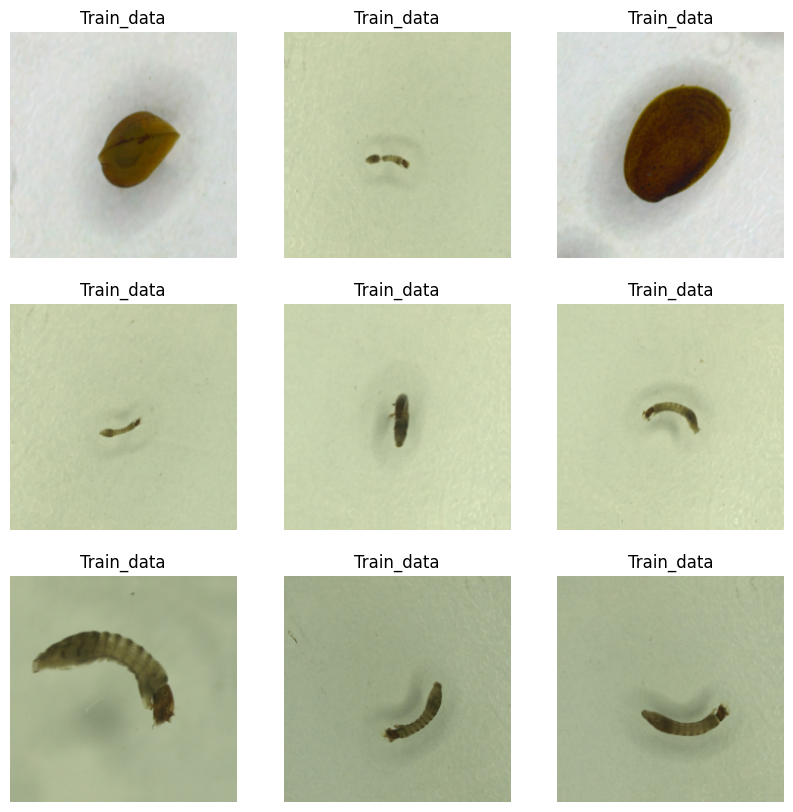

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

Step 4: Build Transfer Learning model

This step builds our classification model. We use the pre-trained MobileNetV2 model to learn useful features. We add our own layers to classify our 3 insect types.

In [9]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze the base model initially

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Step 5: Train the model

This step trains our model with the training data. It runs 10 learning cycles. The model learns to classify images and we check its performance on validation data.

In [11]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9854 - loss: 0.0927 - val_accuracy: 0.9706 - val_loss: 0.2656
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9854 - loss: 0.0791 - val_accuracy: 0.9706 - val_loss: 0.2385
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9854 - loss: 0.0472 - val_accuracy: 0.9706 - val_loss: 0.2103
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.9879 - loss: 0.0401 - val_accuracy: 0.9608 - val_loss: 0.2006
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9903 - loss: 0.0319 - val_accuracy: 0.9608 - val_loss: 0.1939
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.9879 - loss: 0.0319 - val_accuracy: 0.9706 - val_loss: 0.1995
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9903 - loss: 0.0360 - val_accuracy: 0.9608 - val_loss: 0.1960
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9854 - loss: 0.0309 - val_accuracy: 0.9706 - val_loss:

Step 6: Plot training curves

This step draws two charts to show training results. We can see how accuracy and loss change during training to check if the model learns well.

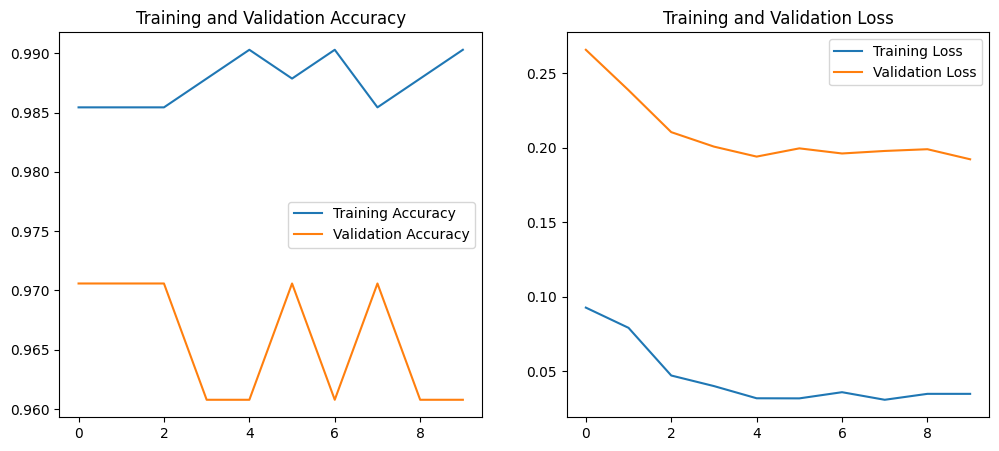

In [12]:
initial_acc = history.history['accuracy']
initial_val_acc = history.history['val_accuracy']
initial_loss = history.history['loss']
initial_val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, initial_acc, label='Training Accuracy')
plt.plot(epochs_range, initial_val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, initial_loss, label='Training Loss')
plt.plot(epochs_range, initial_val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

Step 7: Evaluate on validation set

This step tests the trained model on the validation set. It gives the final accuracy to show how well the model can classify new insect images.

In [13]:
val_loss, val_acc = model.evaluate(val_ds)
print(f'Validation accuracy: {val_acc*100:.2f}%')

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 996ms/step - accuracy: 0.9608 - loss: 0.1921
Validation accuracy: 96.08%


Step 9: Save the trained model

This step saves our trained model to a file. We can reuse it later to predict new pictures without training again.

In [14]:
model.save('insect_classifier_model.h5')
print("Model saved successfully!")

Model saved successfully!


Step 10: Model Evaluation

This step checks model performance in detail. It shows a confusion matrix, precision, recall, F1-score and ROC curves to fully test our model.

<Figure size 600x600 with 0 Axes>

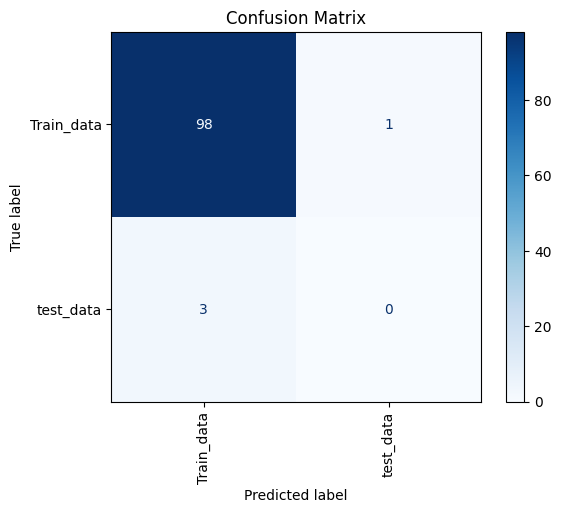

Weighted Precision: 0.9418
Weighted Recall: 0.9608
Weighted F1-score: 0.9512


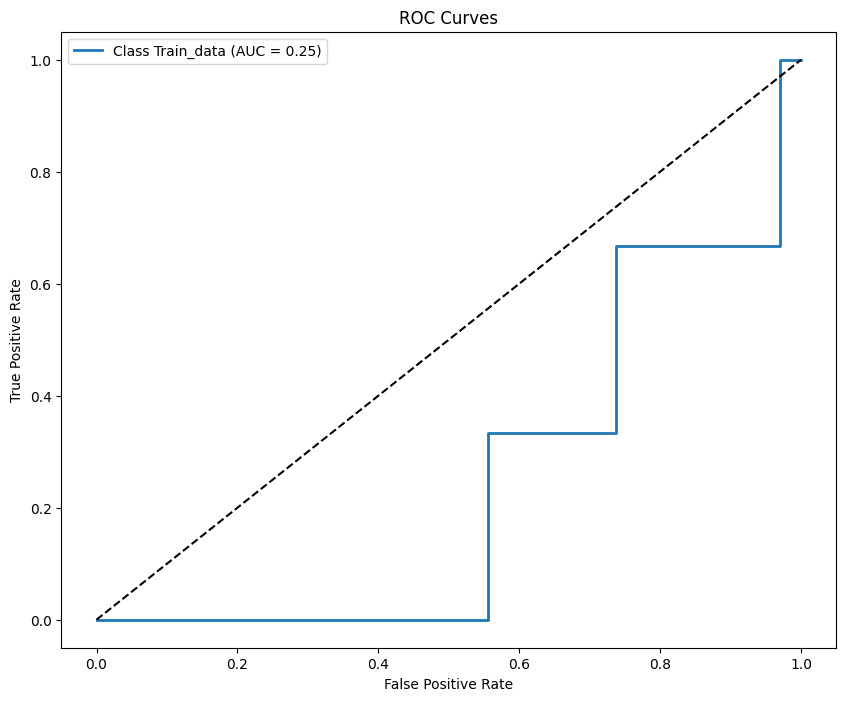

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_fscore_support, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import os
import tensorflow as tf

y_true = []
y_scores = []
y_pred = []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_scores.extend(preds)
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")

y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()
plt.figure(figsize=(10,8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc[i]:0.2f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()